# 11: N* Threshold Exploration

## Objetivo
Explorar numericamente uma fronteira crítica operacional $N^*$ definida por um limiar de visibilidade em um tempo de referência $\tau_{ref}$.

**Definição Operacional:**
$N^*$ é o menor $N$ tal que $V(\tau_{ref}) < V_{threshold}$.

**Tag Epistemológica: PREVISÃO**

> [!WARNING]
> Este notebook é uma exploração numérica de hipóteses de trabalho. Os resultados aqui apresentados são PREVISÕES operacionais e não constituem validação experimental nem derivações do núcleo (core) do repositório.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros de referência
tau_ref = 1.0
V_threshold = 0.1

# Faixa de N
N_range = np.arange(1, 301)

# Constantes (usando as mesmas do scan anterior para consistência)
a = 0.05
b = 0.005

def visibility(tau, gamma):
    return np.exp(-gamma * tau / 2)

# Calcular visibilidade em tau_ref para cada N
V_A = visibility(tau_ref, a * N_range)
V_B = visibility(tau_ref, b * (N_range**2))

print(f"tau_ref: {tau_ref}")
print(f"V_threshold: {V_threshold}")


tau_ref: 1.0
V_threshold: 0.1


In [2]:
def find_n_star(N_vals, V_vals, thresh):
    indices = np.where(V_vals < thresh)[0]
    if len(indices) > 0:
        return N_vals[indices[0]]
    return None

N_star_A = find_n_star(N_range, V_A, V_threshold)
N_star_B = find_n_star(N_range, V_B, V_threshold)

print(f"N*_A (Regime Linear): {N_star_A}")
print(f"N*_B (Regime Quadrático): {N_star_B}")


N*_A (Regime Linear): 93
N*_B (Regime Quadrático): 31


<>:2: SyntaxWarning: invalid escape sequence '\g'
<>:3: SyntaxWarning: invalid escape sequence '\g'
<>:2: SyntaxWarning: invalid escape sequence '\g'
<>:3: SyntaxWarning: invalid escape sequence '\g'
C:\Users\cr_bn\AppData\Local\Temp\ipykernel_12340\1735746703.py:2: SyntaxWarning: invalid escape sequence '\g'
  plt.plot(N_range, V_A, label='Regime A: $\gamma = aN$')
C:\Users\cr_bn\AppData\Local\Temp\ipykernel_12340\1735746703.py:3: SyntaxWarning: invalid escape sequence '\g'
  plt.plot(N_range, V_B, label='Regime B: $\gamma = bN^2$')


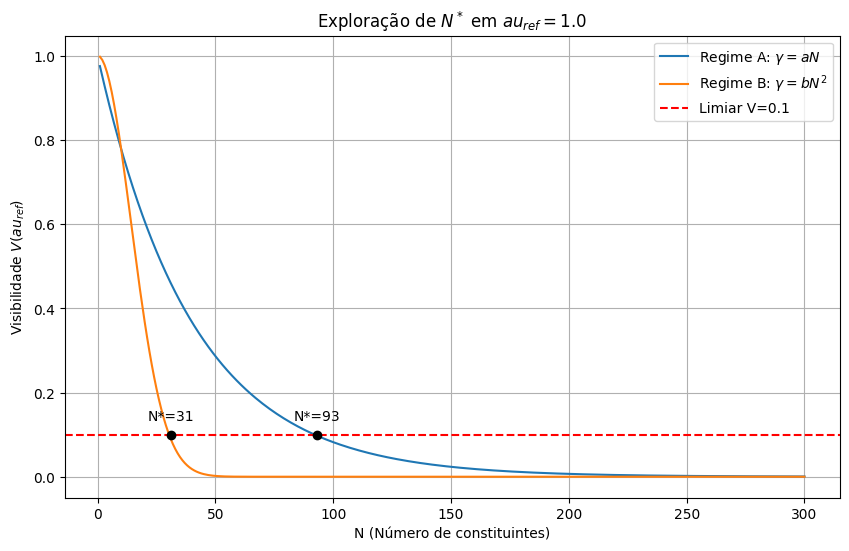

In [3]:
plt.figure(figsize=(10, 6))
plt.plot(N_range, V_A, label='Regime A: $\gamma = aN$')
plt.plot(N_range, V_B, label='Regime B: $\gamma = bN^2$')

plt.axhline(y=V_threshold, color='r', linestyle='--', label=f'Limiar V={V_threshold}')

if N_star_A:
    plt.plot(N_star_A, V_threshold, 'ko')
    plt.annotate(f'N*={N_star_A}', (N_star_A, V_threshold), textcoords="offset points", xytext=(0,10), ha='center')

if N_star_B:
    plt.plot(N_star_B, V_threshold, 'ko')
    plt.annotate(f'N*={N_star_B}', (N_star_B, V_threshold), textcoords="offset points", xytext=(0,10), ha='center')

plt.title(f'Exploração de $N^*$ em $\tau_{{ref}} = {tau_ref}$')
plt.xlabel('N (Número de constituintes)')
plt.ylabel(f'Visibilidade $V(\tau_{{ref}})$')
plt.grid(True)
plt.legend()
plt.show()


## Conclusões de Previsão

Registros:
1. O valor de $N^*$ depende fortemente do modelo de escalonamento assumido para $\gamma$.
2. O regime quadrático ($N^2$) antecipa significativamente a queda da visibilidade abaixo do limiar operacional.
3. Esta análise é uma **previsão operacional** que serve para orientar o desenho de futuros protocolos, não sendo um resultado derivado do core.
